# International Storm Data Analysis Using Python

This project reproduces an international storm analysis workflow originally written in SAS.

The workflow follows five steps:

1. Access Data
2. Explore Data
3. Prepare Data
4. Analyze and Report
5. Export Results

## 1. Access Data

This section imports the source datasets used in the storm analysis.

The project uses:

- One Excel workbook
- Three SAS datasets

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:

PROJECT_DIR = Path.cwd().parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
TABLES_DIR = PROJECT_DIR / "output" / "tables"
FIGURES_DIR = PROJECT_DIR / "output" / "figures"

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DATA_DIR)

Project directory: c:\projects\International_Storm_Analysis
Raw data directory: c:\projects\International_Storm_Analysis\data\raw


In [13]:
# Now load the excel datasets.
storm_damage = pd.read_excel(
    RAW_DATA_DIR / "storm.xlsx",
    sheet_name="Storm_Damage"
)

storm_damage.head()

,Event,Date,Summary,Cost
0,Hurricane Katrina,2005-08-25,Category 3 hurricane initially impacts the U.S...,161300000000
1,Hurricane Harvey,2017-08-25,Category 4 hurricane made landfall near Rockpo...,125000000000
2,Hurricane Maria,2017-09-19,Category 4 hurricane made landfall in southeas...,90000000000
3,Hurricane Sandy,2012-10-30,Extensive damage across several northeastern s...,70900000000
4,Hurricane Irma,2017-09-06,Category 4 hurricane made landfall at Cudjoe K...,50000000000


In [34]:
# Load the SAS datasets

storm_summary = pd.read_sas(
    RAW_DATA_DIR / "storm_summary.sas7bdat",
    format="sas7bdat",
    encoding="latin1"
)

storm_2017 = pd.read_sas(
    RAW_DATA_DIR / "storm_2017.sas7bdat",
    format="sas7bdat",
    encoding="latin1"
)

storm_detail = pd.read_sas(
    RAW_DATA_DIR / "storm_detail.sas7bdat",
    format="sas7bdat",
    encoding="latin1"
)

In [35]:
#Then confirm all four datasets loaded:
print("storm_damage:", storm_damage.shape)
print("storm_summary:", storm_summary.shape)
print("storm_2017:", storm_2017.shape)
print("storm_detail:", storm_detail.shape)

storm_damage: (38, 4)
storm_summary: (3118, 12)
storm_2017: (54, 8)
storm_detail: (50764, 13)


In [17]:
# Inspect the first rows:

display(storm_damage.head())
display(storm_summary.head())
display(storm_2017.head())
display(storm_detail.head())

,Event,Date,Summary,Cost
0,Hurricane Katrina,2005-08-25,Category 3 hurricane initially impacts the U.S...,161300000000
1,Hurricane Harvey,2017-08-25,Category 4 hurricane made landfall near Rockpo...,125000000000
2,Hurricane Maria,2017-09-19,Category 4 hurricane made landfall in southeas...,90000000000
3,Hurricane Sandy,2012-10-30,Extensive damage across several northeastern s...,70900000000
4,Hurricane Irma,2017-09-06,Category 4 hurricane made landfall at Cudjoe K...,50000000000


,Season,Name,Basin,Type,MaxWindMPH,MinPressure,StartDate,EndDate,Hem_NS,Hem_EW,Lat,Lon
0,1980.0,NaN,b'na',b'TS',35.0,NaN,1980-07-17,1980-11-18,b'N',b'W',25.7,-91.2
1,1980.0,NaN,b'SP',b'NR',NaN,998.0,1980-03-27,1980-03-30,b'S',b'E',19.1,137.0
2,1980.0,b'AGATHA',b'EP',b'TS',115.0,NaN,1980-06-09,1980-06-15,b'N',b'W',12.8,-118.7
3,1980.0,b'ALBINE',b'SI',b'ET',NaN,NaN,1979-11-27,1979-12-06,b'S',b'E',19.1,137.0
4,1980.0,b'ALEX',b'WP',b'TS',40.0,998.0,1980-10-09,1980-10-14,b'N',b'E',27.2,140.5


,Year,Basin,Name,StartDate,EndDate,MaxWindMPH,MinPressure,Location
0,2017.0,b'NA',b'ARLENE',2017-04-19,2017-04-21,50.0,990.0,b'None'
1,2017.0,b'NA',b'BRET',2017-06-19,2017-06-20,45.0,1007.0,"b'Guyana, Venezuela, Trinidad and Tobago, Wind..."
2,2017.0,b'NA',b'CINDY',2017-06-20,2017-06-23,60.0,992.0,"b'Honduras, Belize, Cayman Islands, Yucat\xe1n..."
3,2017.0,b'NA',b'DON',2017-07-17,2017-07-18,50.0,1007.0,"b'Windward Islands, Barbados, Grenada, Trinida..."
4,2017.0,b'NA',b'EMILY',2017-07-31,2017-08-02,45.0,1005.0,b'Florida'


,Season,Basin,Sub_basin,Name,ISO_time,Type,Latitude,Longitude,Wind,Pressure,Hem_NS,Hem_EW,Region
0,2000.0,b'SI',b'WA',b'ILSA',1999-12-08 22:00:00,b'NR',-9.0,95.0,25.0,1002.0,b'S',b'E',b'South Pacific/Indian'
1,2000.0,b'SI',b'WA',b'ILSA',1999-12-09 22:00:00,b'NR',-9.2,97.2,25.0,1002.0,b'S',b'E',b'South Pacific/Indian'
2,2000.0,b'SI',b'WA',b'ILSA',1999-12-10 04:00:00,b'NR',-9.3,97.8,25.0,1000.0,b'S',b'E',b'South Pacific/Indian'
3,2000.0,b'SI',b'WA',b'ILSA',1999-12-10 10:00:00,b'NR',-9.8,98.4,30.0,997.0,b'S',b'E',b'South Pacific/Indian'
4,2000.0,b'SI',b'WA',b'ILSA',1999-12-10 16:00:00,b'NR',-10.1,99.0,30.0,997.0,b'S',b'E',b'South Pacific/Indian'


In [36]:
# Finally, inspect the variable names:

print("storm_damage columns:")
print(storm_damage.columns.tolist())

print("\nstorm_summary columns:")
print(storm_summary.columns.tolist())

print("\nstorm_2017 columns:")
print(storm_2017.columns.tolist())

print("\nstorm_detail columns:")
print(storm_detail.columns.tolist())

storm_damage columns:
['Event', 'Date', 'Summary', 'Cost']

storm_summary columns:
['Season', 'Name', 'Basin', 'Type', 'MaxWindMPH', 'MinPressure', 'StartDate', 'EndDate', 'Hem_NS', 'Hem_EW', 'Lat', 'Lon']

storm_2017 columns:
['Year', 'Basin', 'Name', 'StartDate', 'EndDate', 'MaxWindMPH', 'MinPressure', 'Location']

storm_detail columns:
['Season', 'Basin', 'Sub_basin', 'Name', 'ISO_time', 'Type', 'Latitude', 'Longitude', 'Wind', 'Pressure', 'Hem_NS', 'Hem_EW', 'Region']


## 2. Explore Data

This section examines categorical variables, summary statistics, and sample observations from the storm datasets.

Explore Basin and Status Codes

In [37]:
basin_frequency = (
    storm_summary["Basin"]
    .value_counts()
    .rename_axis("Basin")
    .reset_index(name="Frequency")
)

basin_frequency


,Basin,Frequency
0,WP,928
1,EP,671
2,SI,588
3,NA,472
4,SP,359
5,NI,84
6,na,16


In [38]:
type_frequency = (
    storm_summary["Type"]
    .value_counts()
    .rename_axis("Type")
    .reset_index(name="Frequency")
)

type_frequency

,Type,Frequency
0,TS,1357
1,ET,761
2,NR,702
3,DS,293
4,SS,5


In [39]:
summary_statistics = storm_summary[
    ["MaxWindMPH", "MinPressure"]
].describe()

summary_statistics

,MaxWindMPH,MinPressure
count,3095.000000,2922.000000
mean,79.317932,961.854552
std,31.685394,288.658297
min,6.000000,-9999.000000
25%,52.000000,950.000000
50%,75.000000,977.000000
75%,104.000000,992.000000
max,213.000000,1012.000000


In [40]:
storm_summary[
    ["MaxWindMPH", "MinPressure"]
].agg(
    ["count", "mean", "std", "min", "max"]
)

,MaxWindMPH,MinPressure
count,3095.000000,2922.000000
mean,79.317932,961.854552
std,31.685394,288.658297
min,6.000000,-9999.000000
max,213.000000,1012.000000


In [41]:
storm_damage.head()

,Event,Date,Summary,Cost
0,Hurricane Katrina,2005-08-25,Category 3 hurricane initially impacts the U.S...,161300000000
1,Hurricane Harvey,2017-08-25,Category 4 hurricane made landfall near Rockpo...,125000000000
2,Hurricane Maria,2017-09-19,Category 4 hurricane made landfall in southeas...,90000000000
3,Hurricane Sandy,2012-10-30,Extensive damage across several northeastern s...,70900000000
4,Hurricane Irma,2017-09-06,Category 4 hurricane made landfall at Cudjoe K...,50000000000


## 3. Prepare Data

This section cleans, transforms, and combines the storm datasets to prepare them for analysis.

### Step 3.1 — Prepare storm_2017

In [42]:
storm_2017_clean = (
    storm_2017
    .drop(columns=["Location"], errors="ignore")
    .rename(columns={"Year": "Season"})
)

storm_2017_clean.head()

,Season,Basin,Name,StartDate,EndDate,MaxWindMPH,MinPressure
0,2017.0,NA,ARLENE,2017-04-19,2017-04-21,50.0,990.0
1,2017.0,NA,BRET,2017-06-19,2017-06-20,45.0,1007.0
2,2017.0,NA,CINDY,2017-06-20,2017-06-23,60.0,992.0
3,2017.0,NA,DON,2017-07-17,2017-07-18,50.0,1007.0
4,2017.0,NA,EMILY,2017-07-31,2017-08-02,45.0,1005.0


### Step 3.2 — Combine the two datasets

In [43]:
storm_summary2 = pd.concat(
    [storm_summary, storm_2017_clean],
    ignore_index=True
)

storm_summary2.head()

,Season,Name,Basin,Type,MaxWindMPH,MinPressure,StartDate,EndDate,Hem_NS,Hem_EW,Lat,Lon
0,1980.0,NaN,na,TS,35.0,NaN,1980-07-17,1980-11-18,N,W,25.7,-91.2
1,1980.0,NaN,SP,NR,NaN,998.0,1980-03-27,1980-03-30,S,E,19.1,137.0
2,1980.0,AGATHA,EP,TS,115.0,NaN,1980-06-09,1980-06-15,N,W,12.8,-118.7
3,1980.0,ALBINE,SI,ET,NaN,NaN,1979-11-27,1979-12-06,S,E,19.1,137.0
4,1980.0,ALEX,WP,TS,40.0,998.0,1980-10-09,1980-10-14,N,E,27.2,140.5


In [44]:
# Check dimensions:

print("storm_summary:", storm_summary.shape)
print("storm_2017_clean:", storm_2017_clean.shape)
print("storm_summary2:", storm_summary2.shape)

storm_summary: (3118, 12)
storm_2017_clean: (54, 7)
storm_summary2: (3172, 12)


### Step 3.3 — Standardize Basin

In [47]:
storm_summary2["Basin"] = (
    storm_summary2["Basin"]
    .str.upper()
)

In [48]:
storm_summary2["Basin"].head()

0    NA
1    SP
2    EP
3    SI
4    WP
Name: Basin, dtype: str

In [49]:
storm_summary2["Basin"].value_counts()

Basin
WP    928
EP    691
SI    597
NA    505
SP    364
NI     87
Name: count, dtype: int64

### Step 3.4 — Create OceanCode

In [50]:
storm_summary2["OceanCode"] = (
    storm_summary2["Basin"]
    .str[1]
)

In [51]:
storm_summary2[
    ["Basin", "OceanCode"]
].drop_duplicates()

,Basin,OceanCode
0,NA,A
1,SP,P
2,EP,P
3,SI,I
4,WP,P
832,NI,I


### Step 3.5 — Create the matching key

In [118]:
storm_summary2["Season"] = (
    storm_summary2["Season"]
    .astype("Int64")
)

storm_summary2["key"] = (
    storm_summary2["Season"].astype("string")
    + storm_summary2["Name"].str.strip().str.upper()
)

In [119]:
storm_summary2[
    ["Season", "Name", "key"]
].head()

,Season,Name,key
0,1980,<NA>,<NA>
1,1980,<NA>,<NA>
2,1980,AGATHA,1980AGATHA
3,1980,ALBINE,1980ALBINE
4,1980,ALEX,1980ALEX


### Step 3.6 — Calculate storm length

In [120]:
# First convert the date columns:
storm_summary2["StartDate"] = pd.to_datetime(
    storm_summary2["StartDate"]
)

storm_summary2["EndDate"] = pd.to_datetime(
    storm_summary2["EndDate"]
)

In [121]:
# Then calculate the difference:
storm_summary2["StormLength"] = (
    storm_summary2["EndDate"]
    - storm_summary2["StartDate"]
).dt.days

In [122]:
storm_summary2[
    ["Name", "StartDate", "EndDate", "StormLength"]
].head()

,Name,StartDate,EndDate,StormLength
0,<NA>,1980-07-17,1980-11-18,124
1,<NA>,1980-03-27,1980-03-30,3
2,AGATHA,1980-06-09,1980-06-15,6
3,ALBINE,1979-11-27,1979-12-06,9
4,ALEX,1980-10-09,1980-10-14,5


### Step 3.7 — Create Ocean

In [123]:
# IF/ELSE statements like ==> use a mapping dictionary.
ocean_map = {
    "A": "Atlantic",
    "P": "Pacific",
    "I": "Indian"
}

storm_summary2["Ocean"] = (
    storm_summary2["OceanCode"]
    .map(ocean_map)
)

In [124]:
storm_summary2[
    ["Basin", "OceanCode", "Ocean"]
].drop_duplicates()

,Basin,OceanCode,Ocean
0,NA,A,Atlantic
1,SP,P,Pacific
2,EP,P,Pacific
3,SI,I,Indian
4,WP,P,Pacific
832,NI,I,Indian


### Step 3.8 — Create BasinName

In [125]:
basin_map = {
    "NA": "North Atlantic",
    "SA": "South Atlantic",
    "WP": "West Pacific",
    "EP": "East Pacific",
    "SP": "South Pacific",
    "NI": "North Indian",
    "SI": "South Indian"
}

storm_summary2["BasinName"] = (
    storm_summary2["Basin"]
    .map(basin_map)
)

In [126]:
storm_summary2[
    ["Basin", "BasinName"]
].drop_duplicates()

,Basin,BasinName
0,NA,North Atlantic
1,SP,South Pacific
2,EP,East Pacific
3,SI,South Indian
4,WP,West Pacific
832,NI,North Indian


### Step 3.9 — Inspect storm_summary2

In [127]:
storm_summary2[
    [
        "Season",
        "Name",
        "Basin",
        "BasinName",
        "OceanCode",
        "Ocean",
        "StormLength",
        "key"
    ]
].head(10)

,Season,Name,Basin,BasinName,OceanCode,Ocean,StormLength,key
0,1980,<NA>,NA,North Atlantic,A,Atlantic,124,<NA>
1,1980,<NA>,SP,South Pacific,P,Pacific,3,<NA>
2,1980,AGATHA,EP,East Pacific,P,Pacific,6,1980AGATHA
3,1980,ALBINE,SI,South Indian,I,Indian,9,1980ALBINE
4,1980,ALEX,WP,West Pacific,P,Pacific,5,1980ALEX
5,1980,ALLEN,NA,North Atlantic,A,Atlantic,11,1980ALLEN
6,1980,AMY,SI,South Indian,I,Indian,8,1980AMY
7,1980,BERENICE,SI,South Indian,I,Indian,6,1980BERENICE
8,1980,BETTY,WP,West Pacific,P,Pacific,11,1980BETTY
9,1980,BLAS,EP,East Pacific,P,Pacific,3,1980BLAS


### Step 3.10 — Prepare the storm damage dataset

In [128]:
storm_damage2 = storm_damage.copy()

In [129]:
# Convert Date:

storm_damage2["Date"] = pd.to_datetime(
    storm_damage2["Date"]
)

### Step 3.11 — Extract the storm name

In [130]:
storm_damage2["Name"] = (
    storm_damage2["Event"]
    .str.split()
    .str[-1]
    .str.upper()
)

In [131]:
storm_damage2[
    ["Event", "Name"]
].head()

,Event,Name
0,Hurricane Katrina,KATRINA
1,Hurricane Harvey,HARVEY
2,Hurricane Maria,MARIA
3,Hurricane Sandy,SANDY
4,Hurricane Irma,IRMA


### Step 3.12 — Create Season

In [132]:
storm_damage2["Season"] = (
    storm_damage2["Date"]
    .dt.year
)

In [133]:
storm_damage2[
    ["Date", "Season"]
].head()

,Date,Season
0,2005-08-25,2005
1,2017-08-25,2017
2,2017-09-19,2017
3,2012-10-30,2012
4,2017-09-06,2017


### Step 3.13 — Create the matching key

In [134]:
storm_damage2["key"] = (
    storm_damage2["Season"].astype(str)
    + storm_damage2["Name"]
)

In [135]:
storm_damage2[
    ["Season", "Name", "key"]
].head()

,Season,Name,key
0,2005,KATRINA,2005KATRINA
1,2017,HARVEY,2017HARVEY
2,2017,MARIA,2017MARIA
3,2012,SANDY,2012SANDY
4,2017,IRMA,2017IRMA


### Step 3.14 — Drop Event and Date

In [136]:
storm_damage2 = storm_damage2.drop(
    columns=["Event", "Date"]
)

In [137]:
storm_damage2.head()

,Summary,Cost,Name,Season,key
0,Category 3 hurricane initially impacts the U.S...,161300000000,KATRINA,2005,2005KATRINA
1,Category 4 hurricane made landfall near Rockpo...,125000000000,HARVEY,2017,2017HARVEY
2,Category 4 hurricane made landfall in southeas...,90000000000,MARIA,2017,2017MARIA
3,Extensive damage across several northeastern s...,70900000000,SANDY,2012,2012SANDY
4,Category 4 hurricane made landfall at Cudjoe K...,50000000000,IRMA,2017,2017IRMA


### Step 3.15 — Merge the datasets

In [138]:
damage_detail = storm_damage2.merge(
    storm_summary2,
    on="key",
    how="inner",
    suffixes=("_damage", "_storm")
)

In [139]:
damage_detail.head()

,Summary,Cost,Name_damage,Season_damage,key,Season_storm,Name_storm,Basin,Type,MaxWindMPH,...,StartDate,EndDate,Hem_NS,Hem_EW,Lat,Lon,OceanCode,StormLength,Ocean,BasinName
0,Category 3 hurricane initially impacts the U.S...,161300000000,KATRINA,2005,2005KATRINA,2005,KATRINA,NA,ET,173.0,...,2005-08-23,2005-08-31,N,W,26.3,-88.6,A,8,Atlantic,North Atlantic
1,Category 4 hurricane made landfall near Rockpo...,125000000000,HARVEY,2017,2017HARVEY,2017,HARVEY,NA,NaN,130.0,...,2017-08-17,2017-09-01,NaN,NaN,NaN,NaN,A,15,Atlantic,North Atlantic
2,Category 4 hurricane made landfall in southeas...,90000000000,MARIA,2017,2017MARIA,2017,MARIA,NA,NaN,175.0,...,2017-09-16,2017-09-30,NaN,NaN,NaN,NaN,A,14,Atlantic,North Atlantic
3,Extensive damage across several northeastern s...,70900000000,SANDY,2012,2012SANDY,2012,SANDY,NA,ET,115.0,...,2012-10-21,2012-10-31,N,W,20.0,-76.0,A,10,Atlantic,North Atlantic
4,Category 4 hurricane made landfall at Cudjoe K...,50000000000,IRMA,2017,2017IRMA,2017,IRMA,NA,NaN,185.0,...,2017-08-30,2017-09-12,NaN,NaN,NaN,NaN,A,13,Atlantic,North Atlantic


### Step 3.16 — Select the final columns

In [148]:
damage_detail = damage_detail[
    [
        "Name_damage",
        "Season_damage",
        "BasinName",
        "MaxWindMPH",
        "MinPressure",
        "StormLength",
        "Cost"
    ]
]

In [ ]:
# Rename:

damage_detail = damage_detail.rename(
    columns={
        "Name_damage": "Name",
        "Season_damage": "Season"
    }
)

In [150]:
# Sort by cost:

damage_detail = damage_detail.sort_values(
    by="Cost",
    ascending=False
)

In [151]:
damage_detail.head(10)

,Name,Season,BasinName,MaxWindMPH,MinPressure,StormLength,Cost
0,KATRINA,2005,North Atlantic,173.0,902.0,8,161300000000
1,HARVEY,2017,North Atlantic,130.0,938.0,15,125000000000
2,MARIA,2017,North Atlantic,175.0,908.0,14,90000000000
3,SANDY,2012,North Atlantic,115.0,940.0,10,70900000000
4,IRMA,2017,North Atlantic,185.0,914.0,13,50000000000
5,ANDREW,1992,North Atlantic,173.0,922.0,12,48300000000
6,IKE,2008,North Atlantic,144.0,935.0,14,35100000000
7,IVAN,2004,North Atlantic,167.0,910.0,22,27300000000
8,WILMA,2005,North Atlantic,184.0,882.0,11,24500000000
9,RITA,2005,North Atlantic,178.0,895.0,8,23900000000


### Step 3.17 — Save the prepared data

In [152]:
storm_summary2.to_csv(
    PROCESSED_DATA_DIR / "storm_summary_clean.csv",
    index=False
)

damage_detail.to_csv(
    PROCESSED_DATA_DIR / "damage_detail.csv",
    index=False
)

In [153]:
damage_detail.head()

,Name,Season,BasinName,MaxWindMPH,MinPressure,StormLength,Cost
0,KATRINA,2005,North Atlantic,173.0,902.0,8,161300000000
1,HARVEY,2017,North Atlantic,130.0,938.0,15,125000000000
2,MARIA,2017,North Atlantic,175.0,908.0,14,90000000000
3,SANDY,2012,North Atlantic,115.0,940.0,10,70900000000
4,IRMA,2017,North Atlantic,185.0,914.0,13,50000000000


## 4. Analyze and Report

This section analyzes the prepared storm data for a selected year and basin.  
The analysis includes storm frequencies, cross-tabulations, wind statistics, and storm-location visualization.

### Step 4.1 — Define analysis parameters

In [ ]:
# These values let you change the analysis later without rewriting the code.

YEAR = 2016
BASIN = "North Atlantic"

### Step 4.2 — Filter data for the selected year

In [157]:
storms_year = storm_summary2[
    storm_summary2["Season"] == YEAR
].copy()

storms_year.head()

,Season,Name,Basin,Type,MaxWindMPH,MinPressure,StartDate,EndDate,Hem_NS,Hem_EW,Lat,Lon,OceanCode,key,StormLength,Ocean,BasinName
3028,2016,<NA>,NI,NR,35.0,994.0,2016-08-09,2016-11-06,N,E,23.0,89.4,I,<NA>,89,Indian,North Indian
3029,2016,AERE,WP,TS,69.0,975.0,2016-10-04,2016-10-10,N,E,21.2,115.9,P,2016AERE,6,Pacific,West Pacific
3030,2016,AGATHA,EP,DS,52.0,1002.0,2016-07-01,2016-07-08,N,W,16.8,-122.1,P,2016AGATHA,7,Pacific,East Pacific
3031,2016,ALEX,NA,ET,86.0,978.0,2016-01-07,2016-01-17,N,W,30.8,-28.7,A,2016ALEX,10,Atlantic,North Atlantic
3032,2016,AMOS,SP,NR,92.0,965.0,2016-04-20,2016-04-24,S,W,-12.5,-176.3,P,2016AMOS,4,Pacific,South Pacific


In [158]:
print(f"Number of storm records in {YEAR}: {len(storms_year)}")

Number of storm records in 2016: 90


### Step 4.3 — Number of storms by basin

In [159]:
basin_counts = (
    storms_year["BasinName"]
    .value_counts()
    .rename_axis("BasinName")
    .reset_index(name="Frequency")
)

basin_counts

,BasinName,Frequency
0,West Pacific,26
1,East Pacific,23
2,North Atlantic,16
3,South Indian,10
4,South Pacific,9
5,North Indian,6


### Step 4.4 — Create the basin frequency chart

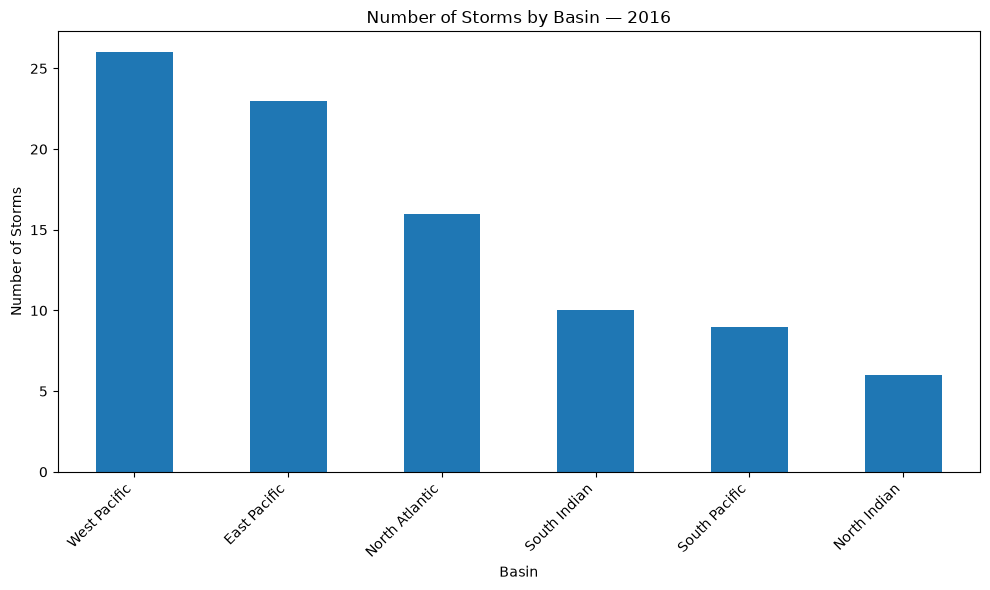

In [160]:
ax = basin_counts.plot(
    x="BasinName",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

ax.set_title(f"Number of Storms by Basin — {YEAR}")
ax.set_xlabel("Basin")
ax.set_ylabel("Number of Storms")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

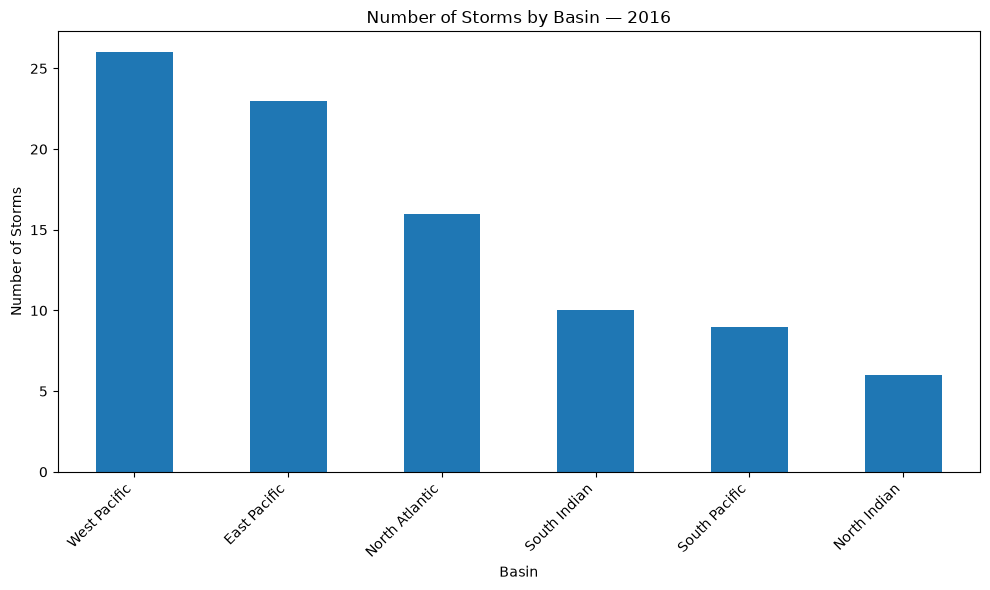

In [161]:
ax = basin_counts.plot(
    x="BasinName",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

ax.set_title(f"Number of Storms by Basin — {YEAR}")
ax.set_xlabel("Basin")
ax.set_ylabel("Number of Storms")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / f"storms_by_basin_{YEAR}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Step 4.5 — Basin × storm type table

In [163]:
basin_type_table = pd.crosstab(
    storms_year["BasinName"],
    storms_year["Type"]
)

basin_type_table

Type,DS,ET,NR,TS
BasinName,,,,
East Pacific,18,0,1,4
North Atlantic,4,9,0,3
North Indian,0,0,6,0
South Indian,0,2,2,6
South Pacific,0,0,9,0
West Pacific,0,13,0,13


In [ ]:

basin_type_table = pd.crosstab(
    storms_year["BasinName"],
    storms_year["Type"],
    margins=True,
    margins_name="Total"
)

basin_type_table

Type,DS,ET,NR,TS,Total
BasinName,,,,,
East Pacific,18,0,1,4,23
North Atlantic,4,9,0,3,16
North Indian,0,0,6,0,6
South Indian,0,2,2,6,10
South Pacific,0,0,9,0,9
West Pacific,0,13,0,13,26
Total,22,24,18,26,90


### Step 4.6 — Wind statistics by storm

In [166]:
storm_detail_year = storm_detail[
    storm_detail["Season"] == YEAR
].copy()

In [167]:
storm_detail_year.head()

,Season,Basin,Sub_basin,Name,ISO_time,Type,Latitude,Longitude,Wind,Pressure,Hem_NS,Hem_EW,Region
47682,2016.0,SI,MM,ANNABELLE,2015-11-18 18:00:00,TS,-4.8,80.4,20.0,1007.0,S,E,South Pacific/Indian
47683,2016.0,SI,MM,ANNABELLE,2015-11-19 00:00:00,TS,-5.7,79.2,20.0,1007.0,S,E,South Pacific/Indian
47684,2016.0,SI,MM,ANNABELLE,2015-11-19 06:00:00,TS,-6.8,78.3,23.0,1006.0,S,E,South Pacific/Indian
47685,2016.0,SI,MM,ANNABELLE,2015-11-19 12:00:00,TS,-8.0,77.3,25.0,1004.0,S,E,South Pacific/Indian
47686,2016.0,SI,MM,ANNABELLE,2015-11-19 18:00:00,TS,-9.1,76.1,25.0,1004.0,S,E,South Pacific/Indian


In [168]:
wind_stats = (
    storm_detail_year
    .groupby("Name")["Wind"]
    .agg(
        AvgWind="mean",
        MinWind="min",
        MaxWind="max"
    )
    .reset_index()
)

wind_stats.head()

,Name,AvgWind,MinWind,MaxWind
0,AERE,42.941176,35.0,60.0
1,AGATHA,30.000000,25.0,45.0
2,ALEX,55.119048,40.0,75.0
3,AMOS,57.368421,30.0,80.0
4,ANNABELLE,35.600000,20.0,55.0


### Step 4.7 — Round wind statistics

In [169]:
wind_stats[
    ["AvgWind", "MinWind", "MaxWind"]
] = wind_stats[
    ["AvgWind", "MinWind", "MaxWind"]
].round(0)

wind_stats.head()

,Name,AvgWind,MinWind,MaxWind
0,AERE,43.0,35.0,60.0
1,AGATHA,30.0,25.0,45.0
2,ALEX,55.0,40.0,75.0
3,AMOS,57.0,30.0,80.0
4,ANNABELLE,36.0,20.0,55.0


### Step 4.8 — Inspect strongest storms

In [170]:
# This gives you the storms with the highest observed wind speeds in 2016.

wind_stats.sort_values(
    "MaxWind",
    ascending=False
).head(10)

,Name,AvgWind,MinWind,MaxWind
85,WINSTON,76.0,25.0,150.0
46,MATTHEW,101.0,50.0,145.0
22,FANTALA,68.0,20.0,135.0
71,SEYMOUR,57.0,15.0,130.0
38,LESTER,78.0,25.0,125.0
5,BLAS,68.0,25.0,120.0
56,NICOLE,64.0,35.0,120.0
49,MERANTI,82.0,35.0,120.0
27,HAIMA,78.0,35.0,115.0
26,GEORGETTE,50.0,20.0,115.0


### Step 4.9 — Prepare the map data

In [171]:
map_data = storm_summary2[
    (storm_summary2["Season"] == YEAR)
    & (storm_summary2["BasinName"] == BASIN)
].copy()

In [172]:
map_data.head()

,Season,Name,Basin,Type,MaxWindMPH,MinPressure,StartDate,EndDate,Hem_NS,Hem_EW,Lat,Lon,OceanCode,key,StormLength,Ocean,BasinName
3031,2016,ALEX,NA,ET,86.0,978.0,2016-01-07,2016-01-17,N,W,30.8,-28.7,A,2016ALEX,10,Atlantic,North Atlantic
3036,2016,BONNIE,NA,ET,46.0,1006.0,2016-05-27,2016-06-09,N,W,30.7,-79.1,A,2016BONNIE,13,Atlantic,North Atlantic
3040,2016,COLIN,NA,ET,58.0,987.0,2016-06-05,2016-06-08,N,W,35.5,-74.4,A,2016COLIN,3,Atlantic,North Atlantic
3043,2016,DANIELLE,NA,DS,46.0,1007.0,2016-06-18,2016-06-21,N,W,20.7,-96.1,A,2016DANIELLE,3,Atlantic,North Atlantic
3047,2016,EARL,NA,TS,86.0,979.0,2016-08-02,2016-08-06,N,W,17.4,-87.8,A,2016EARL,4,Atlantic,North Atlantic


### Step 4.10 — Create map labels

In [173]:
map_data["MapLabel"] = np.where(
    map_data["MaxWindMPH"] >= 100,
    (
        map_data["Name"]
        + "-"
        + map_data["MaxWindMPH"].round(0).astype("Int64").astype(str)
        + " mph"
    ),
    ""
)

In [174]:
map_data = map_data[
    [
        "Lat",
        "Lon",
        "MapLabel",
        "MaxWindMPH"
    ]
]

map_data.head()

,Lat,Lon,MapLabel,MaxWindMPH
3031,30.8,-28.7,,86.0
3036,30.7,-79.1,,46.0
3040,35.5,-74.4,,58.0
3043,20.7,-96.1,,46.0
3047,17.4,-87.8,,86.0


### Step 4.11 — Create the storm-location plot

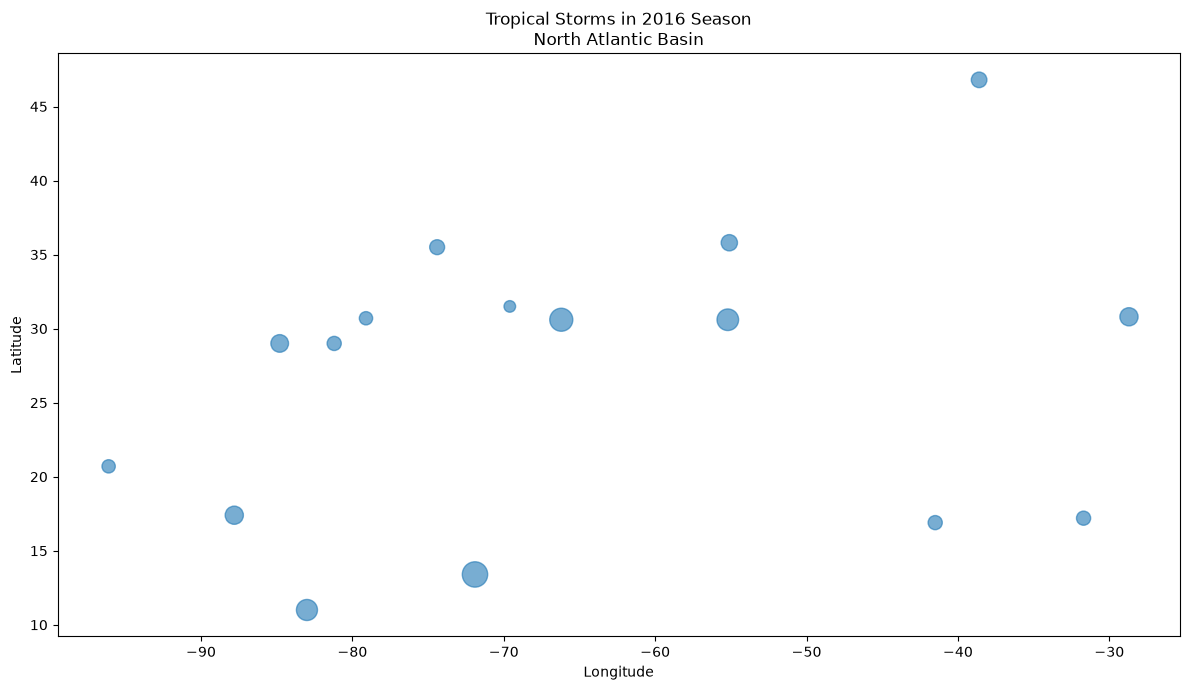

In [176]:
# The bubble size represents maximum wind speed.

plt.figure(figsize=(12, 7))

plt.scatter(
    map_data["Lon"],
    map_data["Lat"],
    s=map_data["MaxWindMPH"] * 2,
    alpha=0.6
)

plt.title(
    f"Tropical Storms in {YEAR} Season\n{BASIN} Basin"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

### Step 4.12 — Add labels for storms ≥100 mph

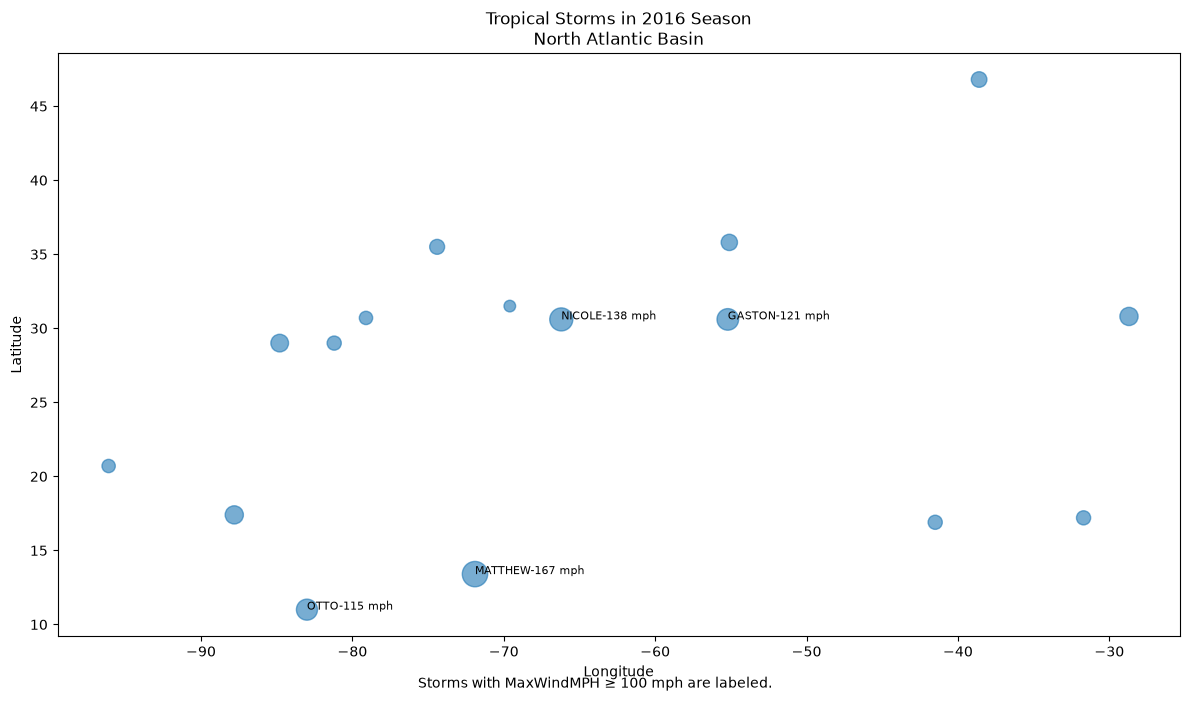

In [177]:
plt.figure(figsize=(12, 7))

plt.scatter(
    map_data["Lon"],
    map_data["Lat"],
    s=map_data["MaxWindMPH"] * 2,
    alpha=0.6
)

for _, row in map_data.iterrows():
    if row["MapLabel"]:
        plt.text(
            row["Lon"],
            row["Lat"],
            row["MapLabel"],
            fontsize=8
        )

plt.title(
    f"Tropical Storms in {YEAR} Season\n{BASIN} Basin"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.figtext(
    0.5,
    0.01,
    "Storms with MaxWindMPH ≥ 100 mph are labeled.",
    ha="center"
)

plt.tight_layout()
plt.show()

### Step 4.13 — Save the storm plot

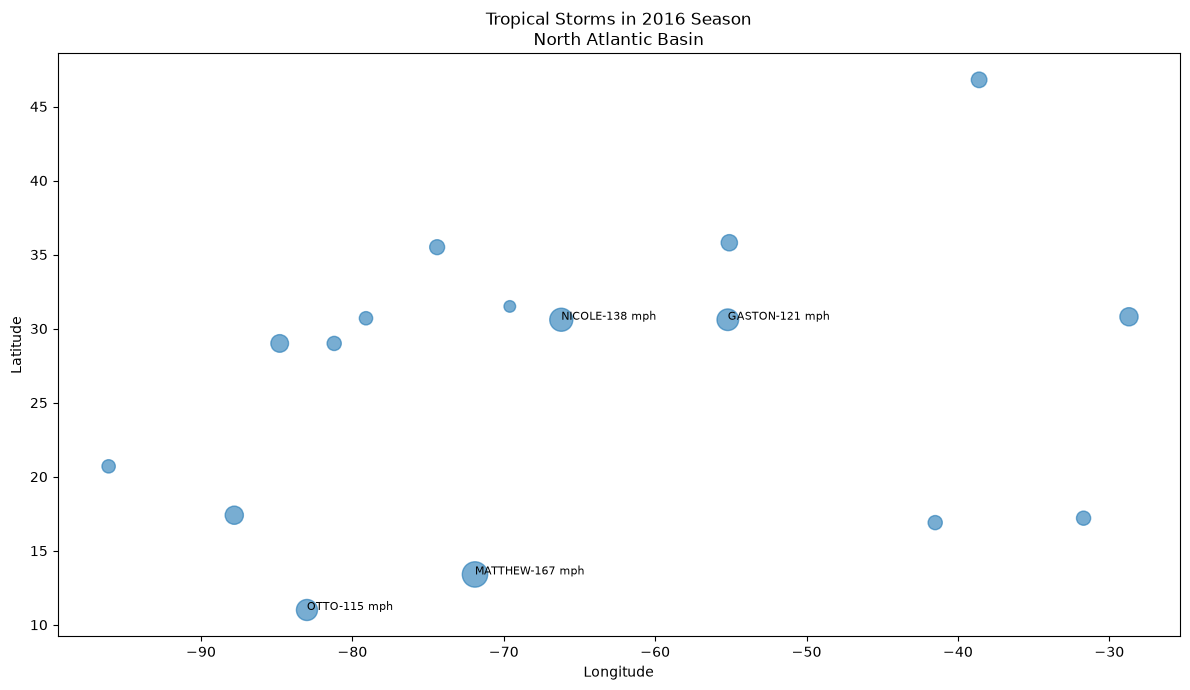

In [178]:
figure_name = (
    f"{YEAR}_{BASIN.lower().replace(' ', '_')}_storms.png"
)

plt.figure(figsize=(12, 7))

plt.scatter(
    map_data["Lon"],
    map_data["Lat"],
    s=map_data["MaxWindMPH"] * 2,
    alpha=0.6
)

for _, row in map_data.iterrows():
    if row["MapLabel"]:
        plt.text(
            row["Lon"],
            row["Lat"],
            row["MapLabel"],
            fontsize=8
        )

plt.title(
    f"Tropical Storms in {YEAR} Season\n{BASIN} Basin"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / figure_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Step 4.14 — Final Section 4 check

In [179]:
print(f"Analysis year: {YEAR}")
print(f"Selected basin: {BASIN}")
print(f"Storm records: {len(storms_year)}")
print(f"Mapped records: {len(map_data)}")
print(f"Storms with wind statistics: {len(wind_stats)}")

Analysis year: 2016
Selected basin: North Atlantic
Storm records: 90
Mapped records: 16
Storms with wind statistics: 88


In [180]:
display(basin_counts)
display(basin_type_table)
display(wind_stats.head(10))

,BasinName,Frequency
0,West Pacific,26
1,East Pacific,23
2,North Atlantic,16
3,South Indian,10
4,South Pacific,9
5,North Indian,6


Type,DS,ET,NR,TS,Total
BasinName,,,,,
East Pacific,18,0,1,4,23
North Atlantic,4,9,0,3,16
North Indian,0,0,6,0,6
South Indian,0,2,2,6,10
South Pacific,0,0,9,0,9
West Pacific,0,13,0,13,26
Total,22,24,18,26,90


,Name,AvgWind,MinWind,MaxWind
0,AERE,43.0,35.0,60.0
1,AGATHA,30.0,25.0,45.0
2,ALEX,55.0,40.0,75.0
3,AMOS,57.0,30.0,80.0
4,ANNABELLE,36.0,20.0,55.0
5,BLAS,68.0,25.0,120.0
6,BOHALE,28.0,20.0,35.0
7,BONNIE,28.0,20.0,40.0
8,CELIA,44.0,25.0,85.0
9,CHABA,78.0,35.0,115.0
